# Notebook 13: Cross-Validation Fold Comparison

This notebook compares 5-fold, 7-fold, and 10-fold cross-validation as candidate validation settings for the project's later workflow.

To keep the notebook self-contained while staying aligned with the main codebase, the key helper logic is written directly inside the notebook in a form that mirrors the corresponding `src` implementations.


## Why Revisit Fold Count?

Once the project moved beyond the early holdout-validation stage, the next methodological question was not only which model to use, but also how to evaluate it reliably. Fold count matters because it changes three practical quantities at the same time:
- the mean CV AUC, which summarizes central validation performance
- the standard deviation across folds, which summarizes stability
- the runtime cost, which affects how practical the validation setting is during iterative development

For this notebook, the main selection criterion is validation stability. The goal is to identify a fold count that keeps the score distribution less noisy, then use mean AUC and runtime as supporting context.


In [2]:
from dataclasses import dataclass
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
LOG_DIR = PROJECT_ROOT / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'diagnosed_diabetes'
RANDOM_SEED = 42
MAX_TRAIN_ROWS = None
FOLD_OPTIONS = [5, 7, 10]
PREFERRED_FOLD = 7

ARTIFACT_CSV = LOG_DIR / 'fold_count_comparison.csv'
ARTIFACT_JSON = LOG_DIR / 'fold_count_comparison.json'
ARTIFACT_MD = LOG_DIR / 'fold_count_comparison.md'
ARTIFACT_PNG = LOG_DIR / 'fold_count_comparison.png'

CATEGORICAL_COLS = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

if hasattr(sns, 'set_theme'):
    sns.set_theme(style='whitegrid', context='talk')
else:
    sns.set_style('whitegrid')
    sns.set_context('talk')
plt.rcParams['figure.figsize'] = (10, 6)


@dataclass
class ExperimentConfig:
    use_family_history_features: bool = True
    use_cholesterol_features: bool = True


CONFIG = ExperimentConfig()


def add_engineered_features(df: pd.DataFrame, config: ExperimentConfig = None) -> pd.DataFrame:
    if config is None:
        config = ExperimentConfig()

    df = df.copy()

    if config.use_family_history_features:
        df['age_family_history'] = df['age'] * df['family_history_diabetes']
        df['age_bmi'] = df['age'] * df['bmi']
        df['cardio_risk_score'] = (
            df['family_history_diabetes'] * 3
            + df['hypertension_history'] * 2
            + df['cardiovascular_history'] * 2
        )

    if config.use_cholesterol_features:
        df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
        df['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']

    return df


def build_xgb_model(seed: int = RANDOM_SEED) -> XGBClassifier:
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        early_stopping_rounds=100,
        verbosity=0,
    )


def load_data(sample_cap=None) -> pd.DataFrame:
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    if sample_cap is not None and len(train_df) > sample_cap:
        train_df = train_df.iloc[:sample_cap].reset_index(drop=True)
    return train_df


def prepare_features(train_df: pd.DataFrame, config: ExperimentConfig = None):
    if config is None:
        config = ExperimentConfig()

    X = train_df.drop(columns=['id', TARGET]).copy()
    y = train_df[TARGET].astype(int).copy()

    X = add_engineered_features(X, config)

    categorical_cols = [col for col in CATEGORICAL_COLS if col in X.columns]
    for col in categorical_cols:
        X[col] = X[col].fillna('Unknown').astype(str)

    return X, y, categorical_cols


def _encode_categorical_fold(
    X_train_raw: pd.DataFrame,
    X_valid_raw: pd.DataFrame,
    categorical_cols,
):
    X_train_encoded = X_train_raw.copy()
    X_valid_encoded = X_valid_raw.copy()

    for col in categorical_cols:
        if col not in X_train_encoded.columns:
            continue

        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))

        try:
            X_valid_encoded[col] = le.transform(X_valid_encoded[col].astype(str))
        except ValueError:
            X_valid_encoded[col] = -1

    missing_valid = set(X_train_encoded.columns) - set(X_valid_encoded.columns)
    for col in missing_valid:
        X_valid_encoded[col] = 0
    X_valid_encoded = X_valid_encoded[X_train_encoded.columns]

    return X_train_encoded, X_valid_encoded


def run_standard_xgb_cv_benchmark(X, y, categorical_cols, random_state=RANDOM_SEED, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(X))
    fold_scores = []
    best_iterations = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train_raw = X.iloc[train_idx]
        X_valid_raw = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        X_train_encoded, X_valid_encoded = _encode_categorical_fold(
            X_train_raw, X_valid_raw, categorical_cols
        )

        model = build_xgb_model(seed=random_state + fold)
        model.fit(
            X_train_encoded,
            y_train,
            eval_set=[(X_valid_encoded, y_valid)],
            verbose=False,
        )

        valid_pred = model.predict_proba(X_valid_encoded)[:, 1]
        fold_auc = roc_auc_score(y_valid, valid_pred)
        oof_pred[valid_idx] = valid_pred
        fold_scores.append(float(fold_auc))
        best_iterations.append(getattr(model, 'best_iteration', None))

    return {
        'fold_aucs': fold_scores,
        'mean_auc': float(np.mean(fold_scores)),
        'std_auc': float(np.std(fold_scores)),
        'oof_auc': float(roc_auc_score(y, oof_pred)),
        'best_iterations': best_iterations,
        'oof_pred': oof_pred,
    }


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return '| empty |\n| --- |'
    columns = [str(col) for col in df.columns]
    header = '| ' + ' | '.join(columns) + ' |'
    separator = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for _, row in df.iterrows():
        cells = []
        for value in row.tolist():
            if isinstance(value, float):
                cells.append(f'{value:.6f}')
            else:
                cells.append(str(value))
        rows.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join([header, separator, *rows])


print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Artifacts directory: {LOG_DIR}')
print(f'Max train rows: {MAX_TRAIN_ROWS}')
print(f'Fold options: {FOLD_OPTIONS}')


Project root: c:\Users\LENOVO\Desktop\machinelearning_project
Data directory: c:\Users\LENOVO\Desktop\machinelearning_project\data
Artifacts directory: c:\Users\LENOVO\Desktop\machinelearning_project\logs
Max train rows: None
Fold options: [5, 7, 10]


## Data Loading and Feature Preparation

This section loads the raw training data directly from the repository and prepares features using notebook-local code that mirrors the main `src` pipeline. The feature engineering logic is aligned with the project implementation, but it is defined inline here so the notebook remains standalone.

The default setting uses the full training set. In this repository, that means all **700,000** training rows are included unless you manually set `MAX_TRAIN_ROWS` to a smaller value for a faster exploratory run.


In [3]:
train_df = load_data(sample_cap=MAX_TRAIN_ROWS)
X, y, categorical_cols = prepare_features(train_df, config=CONFIG)

if MAX_TRAIN_ROWS is None:
    print(f'Using the full training set: {len(train_df):,} rows')
else:
    print(f'Using a capped training set: {len(train_df):,} rows')

overview_df = pd.DataFrame(
    {
        'rows': [len(train_df)],
        'feature_count': [X.shape[1]],
        'categorical_features': [len(categorical_cols)],
        'target_positive_rate': [float(y.mean())],
    }
)

display(overview_df)
X.head()


Using the full training set: 700,000 rows


,rows,feature_count,categorical_features,target_positive_rate
0,700000,29,6,0.623296


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,age_family_history,age_bmi,cardio_risk_score,cholesterol_ratio,non_hdl_cholesterol
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Current,Employed,0,0,0,0,1035.4,0,3.372881,141
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Never,Employed,0,0,0,0,1190.0,0,3.901961,149
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Never,Retired,0,0,0,0,771.2,0,3.133333,129
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Current,Employed,0,1,0,0,1436.4,2,3.309091,128
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Never,Retired,0,1,0,0,1555.2,2,4.120000,157


## Method

For each candidate fold count, the notebook runs the same ordinary stratified XGBoost cross-validation benchmark and records:
- fold-level AUCs
- mean CV AUC
- standard deviation of CV AUC
- OOF AUC
- elapsed runtime

The notebook is intended to be numerically consistent with the main `src` training path when the fold count is set to 7 and the full training set is used. The main decision signal remains the standard deviation across folds. Mean AUC and runtime remain useful secondary checks, but the final fold-count choice is driven primarily by validation stability.


In [9]:
rows = []
benchmark_details = {}

for n_splits in FOLD_OPTIONS:
    start = time.perf_counter()
    benchmark = run_standard_xgb_cv_benchmark(
        X=X,
        y=y,
        categorical_cols=categorical_cols,
        random_state=RANDOM_SEED,
        n_splits=n_splits,
    )
    elapsed = time.perf_counter() - start

    row = {
        'fold_count': n_splits,
        'fold_aucs': benchmark['fold_aucs'],
        'mean_auc': benchmark['mean_auc'],
        'std_auc': benchmark['std_auc'],
        'oof_auc': benchmark['oof_auc'],
        'runtime_seconds': float(elapsed),
        'preferred_fold': n_splits == PREFERRED_FOLD,
    }
    rows.append(row)
    benchmark_details[n_splits] = benchmark

results_df = pd.DataFrame(rows).sort_values('fold_count').reset_index(drop=True)
results_df

MemoryError: Unable to allocate 25.6 MiB for an array with shape (6, 560000) and data type object

## Results Table

The comparison table below is the main decision surface for this notebook. In practice, the most useful columns are:
- `mean_auc` for central validation performance
- `std_auc` for stability
- `runtime_seconds` for development cost

A fold count that is only marginally stronger in AUC but substantially heavier in runtime may not be the best operating point for an iterative course-project workflow.

In [4]:
display_df = results_df.copy()
display_df['fold_aucs'] = display_df['fold_aucs'].apply(
    lambda scores: ', '.join(f'{score:.4f}' for score in scores)
)
display_df['mean_auc'] = display_df['mean_auc'].map(lambda x: f'{x:.6f}')
display_df['std_auc'] = display_df['std_auc'].map(lambda x: f'{x:.6f}')
display_df['oof_auc'] = display_df['oof_auc'].map(lambda x: f'{x:.6f}')
display_df['runtime_seconds'] = display_df['runtime_seconds'].map(lambda x: f'{x:.2f}')

display(display_df)

,fold_count,fold_aucs,mean_auc,std_auc,oof_auc,runtime_seconds,preferred_fold
0,5,"0.7260, 0.7243, 0.7252, 0.7267, 0.7259",0.725611,0.000835,0.725604,413.66,False
1,7,"0.7256, 0.7258, 0.7259, 0.7238, 0.7259, 0.7286...",0.725852,0.001294,0.725845,504.85,True
2,10,"0.7257, 0.7271, 0.7244, 0.7245, 0.7257, 0.7254...",0.725908,0.001466,0.725905,741.51,False


## Visualization

The visualization now foregrounds the notebook's actual decision rule: **lower fold-to-fold variance is better**.

The two panels play different roles:
- the left panel is the primary decision plot and shows `std_auc` directly
- the right panel provides secondary context through mean AUC and runtime

Under this framing, the preferred fold count should stand out first as the most stable option, not merely as a compromise between larger and smaller fold counts.


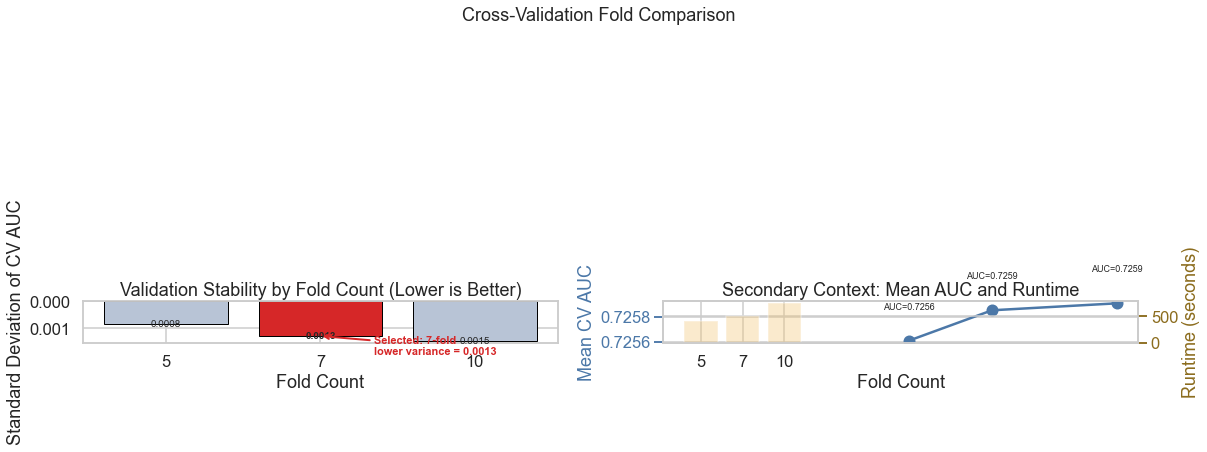

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

preferred_mask = results_df['fold_count'] == PREFERRED_FOLD
std_colors = ['#b8c4d6' if not is_preferred else '#d62728' for is_preferred in preferred_mask]

bars = axes[0].bar(results_df['fold_count'].astype(str), results_df['std_auc'], color=std_colors, edgecolor='black', linewidth=1.0)
axes[0].set_xlabel('Fold Count')
axes[0].set_ylabel('Standard Deviation of CV AUC')
axes[0].set_title('Validation Stability by Fold Count (Lower is Better)')
axes[0].invert_yaxis()

for bar, (_, row) in zip(bars, results_df.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        row['std_auc'] - 0.00015,
        f"{row['std_auc']:.4f}",
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold' if row['fold_count'] == PREFERRED_FOLD else 'normal',
    )

preferred_row = results_df.loc[preferred_mask].iloc[0]
axes[0].annotate(
    f"Selected: {PREFERRED_FOLD}-fold\nlower variance = {preferred_row['std_auc']:.4f}",
    xy=(list(results_df['fold_count'].astype(str)).index(str(PREFERRED_FOLD)), preferred_row['std_auc']),
    xytext=(1.35, preferred_row['std_auc'] + 0.0007),
    textcoords='data',
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=2),
    fontsize=11,
    color='#d62728',
    fontweight='bold',
)

mean_line_color = '#4c78a8'
runtime_bar_color = '#f2c572'
runtime_ax = axes[1].twinx()

axes[1].plot(results_df['fold_count'], results_df['mean_auc'], marker='o', linewidth=2.5, color=mean_line_color)
axes[1].scatter(results_df['fold_count'], results_df['mean_auc'], s=110, color=mean_line_color, zorder=3)
runtime_ax.bar(results_df['fold_count'].astype(str), results_df['runtime_seconds'], alpha=0.35, color=runtime_bar_color)

for _, row in results_df.iterrows():
    axes[1].text(row['fold_count'], row['mean_auc'] + 0.00025, f"AUC={row['mean_auc']:.4f}", ha='center', fontsize=9)

axes[1].set_xlabel('Fold Count')
axes[1].set_ylabel('Mean CV AUC', color=mean_line_color)
runtime_ax.set_ylabel('Runtime (seconds)', color='#8c6d1f')
axes[1].set_title('Secondary Context: Mean AUC and Runtime')
axes[1].tick_params(axis='y', colors=mean_line_color)
runtime_ax.tick_params(axis='y', colors='#8c6d1f')

for tick_label in axes[0].get_xticklabels():
    if tick_label.get_text() == str(PREFERRED_FOLD):
        tick_label.set_color('#d62728')
        tick_label.set_fontweight('bold')
for tick_label in axes[1].get_xticklabels():
    if tick_label.get_text() == str(PREFERRED_FOLD):
        tick_label.set_color('#d62728')
        tick_label.set_fontweight('bold')

fig.suptitle('Cross-Validation Fold Comparison', fontsize=18, y=1.03)
fig.tight_layout()
fig.savefig(ARTIFACT_PNG, dpi=180, bbox_inches='tight')
plt.show()


## Recommendation Logic

This notebook treats lower fold-to-fold variance as the main selection criterion. Under that framing:
- 5-fold remains the lighter reference setting
- 10-fold remains the heavier alternative
- 7-fold is preferred because it provides the lower-variance operating point we want for the project's final validation setting

When this notebook is run on the full training set, the 7-fold row should also align with the corresponding `src` training result, because the model, preprocessing, and CV logic are intentionally matched.


In [6]:
preferred_row = results_df.loc[results_df['fold_count'] == PREFERRED_FOLD].iloc[0]
best_mean_row = results_df.loc[results_df['mean_auc'].idxmax()]
lowest_std_row = results_df.loc[results_df['std_auc'].idxmin()]
fastest_row = results_df.loc[results_df['runtime_seconds'].idxmin()]

recommendation_lines = [
    f"**Recommended validation setting: {PREFERRED_FOLD}-fold cross-validation**",
    '',
    f"- Mean AUC for {PREFERRED_FOLD}-fold: **{preferred_row['mean_auc']:.6f}**",
    f"- Standard deviation for {PREFERRED_FOLD}-fold: **{preferred_row['std_auc']:.6f}**",
    f"- Lowest fold-to-fold standard deviation in this run: **{int(lowest_std_row['fold_count'])}-fold** ({lowest_std_row['std_auc']:.6f})",
    f"- Highest mean AUC in this run: **{int(best_mean_row['fold_count'])}-fold** ({best_mean_row['mean_auc']:.6f})",
    f"- Fastest runtime in this run: **{int(fastest_row['fold_count'])}-fold** ({fastest_row['runtime_seconds']:.2f} seconds)",
    '',
    f"The primary reason for selecting {PREFERRED_FOLD}-fold is its lower fold-to-fold variance, which makes it the more stable validation setting for the project's final workflow.",
    "Mean AUC and runtime are still useful context, but they play a secondary role in this notebook's final choice.",
]

display(Markdown('\n'.join(recommendation_lines)))


**Recommended validation setting: 7-fold cross-validation**

- Mean AUC for 7-fold: **0.725852**
- Standard deviation for 7-fold: **0.001294**
- Lowest fold-to-fold standard deviation in this run: **5-fold** (0.000835)
- Highest mean AUC in this run: **10-fold** (0.725908)
- Fastest runtime in this run: **5-fold** (413.66 seconds)

The primary reason for selecting 7-fold is its lower fold-to-fold variance, which makes it the more stable validation setting for the project's final workflow.
Mean AUC and runtime are still useful context, but they play a secondary role in this notebook's final choice.

## Save Artifacts

The notebook exports its comparison table, summary payload, markdown report, and main plot to `logs/`. These artifacts are generated by the notebook itself, so no earlier notebook execution is required.

In [7]:
summary_payload = {
    'max_train_rows': None if MAX_TRAIN_ROWS is None else int(MAX_TRAIN_ROWS),
    'preferred_fold': int(PREFERRED_FOLD),
    'selection_reason': '7-fold is selected because it has lower fold-to-fold variance.',
    'results': results_df.to_dict(orient='records'),
}

results_df.to_csv(ARTIFACT_CSV, index=False)
with open(ARTIFACT_JSON, 'w', encoding='utf-8') as handle:
    json.dump(summary_payload, handle, indent=2)

markdown_lines = [
    '# Fold Count Comparison',
    '',
    '## Comparison Results',
    dataframe_to_markdown(results_df[['fold_count', 'mean_auc', 'std_auc', 'oof_auc', 'runtime_seconds', 'preferred_fold']]),
    '',
    '## Recommendation',
    f'- Preferred validation setting: {PREFERRED_FOLD}-fold',
    f'- Primary reason: {PREFERRED_FOLD}-fold is selected because it has lower fold-to-fold variance.',
    '- Mean AUC and runtime remain supporting diagnostics rather than the main decision rule.',
]
ARTIFACT_MD.write_text(chr(10).join(markdown_lines), encoding='utf-8')

print(f'Saved comparison table: {ARTIFACT_CSV}')
print(f'Saved summary JSON: {ARTIFACT_JSON}')
print(f'Saved markdown summary: {ARTIFACT_MD}')
print(f'Saved plot: {ARTIFACT_PNG}')


Saved comparison table: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.csv
Saved summary JSON: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.json
Saved markdown summary: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.md
Saved plot: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.png


## Final Narrative Link

Notebook 12 studies tail-based validation behavior, while this notebook focuses on classical cross-validation design. Together they show that evaluation strategy became a central part of the project, not just a background implementation detail.

Within that story, Notebook 13 contributes the specific decision that 7-fold becomes the final CV setting because it shows lower variance across folds. Notebook 13.5 then uses this choice as part of the overall experiment summary.
